### 1. Import Library

Pada tahap ini, dilakukan import berbagai library yang akan digunakan untuk proses pengolahan data, pelatihan model, dan evaluasi model machine learning.

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

### 2. Load Dataset & Pembersihan Awal

In [2]:
df = pd.read_csv("agro_environmental_dataset.csv")

# Drop ID
df = df.drop(columns=["location_id"])

print(df.shape)
df.head()

(543210, 24)


,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,moisture_regime,soil_temp_c,air_temp_c,thermal_regime,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,dry,21.1,25.6,optimal,1027.0,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,optimal,30.7,30.3,heat_stress,563.0,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,waterlogged,30.3,34.1,heat_stress,408.0,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,optimal,26.8,30.2,optimal,729.0,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,optimal,22.6,25.9,optimal,339.0,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


### 3. Exploratory Data Analysis
#### 3.1 Distribusi Target (Failure Flag)

Visualisasi ini digunakan untuk melihat sebaran kelas pada variabel target failure_flag. Hal ini penting untuk mengetahui apakah dataset mengalami ketidakseimbangan kelas (class imbalance) antara kondisi gagal (1) dan tidak gagal (0), yang dapat mempengaruhi performa model machine learning.

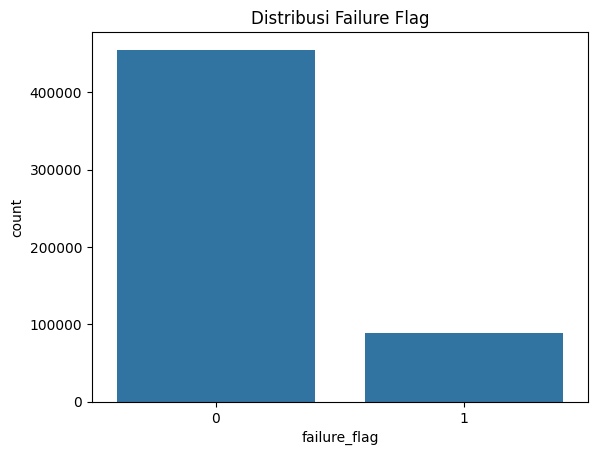

In [3]:
sns.countplot(x="failure_flag", data=df)
plt.title("Distribusi Failure Flag")
plt.show()

#### 3.2 Heatmap Korelasi
Visualisasi ini digunakan untuk melihat hubungan (korelasi) antar fitur numerik dalam dataset. Heatmap membantu mengidentifikasi fitur yang memiliki hubungan kuat atau lemah satu sama lain, sehingga dapat digunakan untuk analisis lebih lanjut dalam proses feature selection dan pemodelan machine learning.

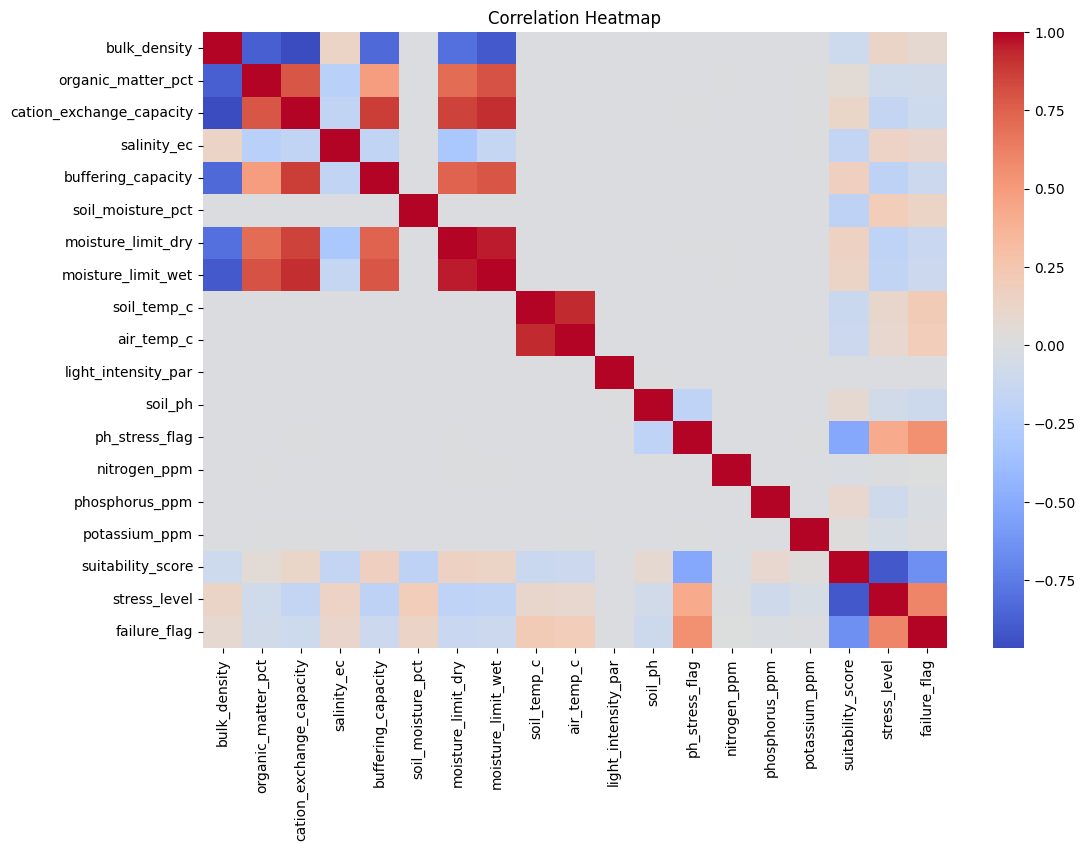

In [4]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### 4. Data Cleaning
Tahap ini dilakukan untuk membersihkan data sebelum proses pemodelan. Duplikasi data dihapus agar tidak menyebabkan bias pada model, sedangkan pengecekan missing value dilakukan untuk memastikan tidak ada data kosong yang dapat mengganggu proses training model.

In [5]:
# Hapus Duplikat
df = df.drop_duplicates()

# Cek missing
print(df.isnull().sum())

soil_type                   0
bulk_density                0
organic_matter_pct          0
cation_exchange_capacity    0
salinity_ec                 0
buffering_capacity          0
soil_moisture_pct           0
moisture_limit_dry          0
moisture_limit_wet          0
moisture_regime             0
soil_temp_c                 0
air_temp_c                  0
thermal_regime              0
light_intensity_par         0
soil_ph                     0
ph_stress_flag              0
nitrogen_ppm                0
phosphorus_ppm              0
potassium_ppm               0
nutrient_balance            0
plant_category              0
suitability_score           0
stress_level                0
failure_flag                0
dtype: int64


#### 5. Feature Selection
Pada tahap ini dilakukan penghapusan beberapa fitur yang berpotensi menyebabkan data leakage, yaitu kondisi ketika informasi pada data input secara tidak langsung sudah mengandung informasi dari target label. Fitur seperti moisture_regime, thermal_regime, nutrient_balance, dan ph_stress_flag merupakan variabel turunan yang sangat dekat dengan kondisi target, sehingga jika digunakan dapat membuat model “terlalu mudah” belajar dan menghasilkan performa yang tidak realistis. Oleh karena itu, fitur tersebut dihapus untuk memastikan model belajar dari fitur yang benar-benar independen.

In [6]:
leakage_cols = [
    "moisture_regime",
    "thermal_regime",
    "nutrient_balance",
    "ph_stress_flag"
]

df = df.drop(columns=leakage_cols)

#### 6. Feature Engineering
Pada tahap ini dilakukan pembuatan fitur baru untuk menangkap hubungan yang lebih kompleks antara kondisi tanah, nutrisi, dan lingkungan terhadap kondisi tanaman.

In [7]:
# Moisture threshold
df["moisture_deficit"] = df["soil_moisture_pct"] - df["moisture_limit_dry"]
df["moisture_excess"] = df["soil_moisture_pct"] - df["moisture_limit_wet"]

# pH deviation
df["ph_deviation"] = abs(df["soil_ph"] - 6.5)

# Interaction
df["salinity_stress"] = df["salinity_ec"] * df["soil_moisture_pct"]

# Nutrient ratio
df["np_ratio"] = df["nitrogen_ppm"] / (df["phosphorus_ppm"] + 1)
df["nk_ratio"] = df["nitrogen_ppm"] / (df["potassium_ppm"] + 1)

# Soil-aware normalization
df["moisture_z_by_soil"] = df.groupby("soil_type")["soil_moisture_pct"]\
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

#### 7. Pemisahan Fitur (X) dan Target (y)
Pada tahap ini dataset dipisahkan menjadi fitur (X) dan target (y).
- X (features): berisi semua variabel input yang digunakan untuk memprediksi kondisi tanaman.
- y (target): berisi variabel failure_flag yang menunjukkan apakah tanaman gagal (1) atau tidak gagal (0).

Kolom suitability_score dan stress_level juga dihapus dari fitur karena merupakan variabel turunan dari kondisi yang berhubungan langsung dengan target, sehingga tidak digunakan untuk menghindari potensi data leakage.

In [8]:
X = df.drop(columns=["failure_flag", "suitability_score", "stress_level"])
y = df["failure_flag"]

# cek distribusi kelas
print(y.value_counts(normalize=True))

# handle imbalance
class_weight = "balanced"

failure_flag
0    0.837853
1    0.162147
Name: proportion, dtype: float64


#### 8. Train-Test Split Data
Data dibagi menjadi data training (80%) dan testing (20%) untuk melatih dan menguji model. Parameter stratify=y digunakan agar proporsi kelas tetap seimbang pada data train dan test.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### 9. Preprocessing Data
Pada tahap ini dilakukan preprocessing data dengan memisahkan fitur numerik dan kategorikal, di mana cat_cols merupakan kolom kategori yang akan di-encode menjadi bentuk numerik, sedangkan num_cols merupakan kolom numerik yang akan distandarisasi. ColumnTransformer digunakan untuk menggabungkan kedua proses tersebut, yaitu menerapkan StandardScaler pada data numerik agar memiliki skala yang seragam dan OneHotEncoder pada data kategorikal agar dapat diproses oleh model machine learning.

In [10]:
cat_cols = ["soil_type", "plant_category"]
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

#### 10. Model Pipeline: Random Forest
Pada tahap ini dibuat pipeline yang menggabungkan proses preprocessing dan model machine learning dalam satu alur. Data terlebih dahulu diproses menggunakan preprocessor, kemudian dimasukkan ke dalam model RandomForestClassifier untuk melakukan klasifikasi. Parameter class_weight="balanced" digunakan untuk mengatasi ketidakseimbangan kelas, sedangkan random_state=42 memastikan hasil yang konsisten setiap kali dijalankan.

In [11]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

#### 11. Hyperparameter Tuning (Random Forest)
Tahap ini dilakukan untuk mencari kombinasi hyperparameter terbaik pada model Random Forest menggunakan GridSearchCV. Parameter seperti jumlah pohon (n_estimators), kedalaman pohon (max_depth), dan minimum sampel pada leaf (min_samples_leaf) diuji untuk mendapatkan performa terbaik. Proses validasi menggunakan StratifiedKFold agar distribusi kelas tetap seimbang pada setiap fold, dan evaluasi menggunakan metrik ROC-AUC untuk mengukur kemampuan model dalam membedakan kelas. Hasil terbaik kemudian disimpan dalam rf_best.

In [12]:
param_grid = {
    "clf__n_estimators": [200, 300],
    "clf__max_depth": [10, 15],
    "clf__min_samples_leaf": [2, 4]
}

cv = StratifiedKFold(n_splits=3)

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)
rf_best = grid_rf.best_estimator_

Best RF Params: {'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 300}


#### 12. Evaluasi Model
Fungsi ini digunakan untuk mengevaluasi performa model pada data testing. Model akan menghasilkan prediksi kelas (y_pred) dan probabilitas (y_prob). Hasil evaluasi ditampilkan dalam bentuk classification report yang berisi precision, recall, dan f1-score, serta nilai ROC-AUC untuk mengukur kemampuan model dalam membedakan kelas gagal (1) dan tidak gagal (0).

In [19]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
    print("F1 Score :", round(f1_score(y_test, y_pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))

evaluate(rf_best, "Random Forest")


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     91026
           1       0.94      0.95      0.95     17616

    accuracy                           0.98    108642
   macro avg       0.97      0.97      0.97    108642
weighted avg       0.98      0.98      0.98    108642

Accuracy : 0.982
F1 Score : 0.946
ROC-AUC  : 0.997


#### 13. Menyimpan Model Terlatih
Pada tahap ini, model terbaik (rf_best) yang telah dilatih disimpan ke dalam file model.pkl menggunakan library joblib.

In [14]:
import joblib
joblib.dump(rf_best, "model.pkl")

['model.pkl']